# EEE205 Artificial Intelligence I
## Tutorial solutions
## Part 15 - metrics and validation
## Credit Card Fraud Detection
### Barry Dillon

# Part 1

1. Give definitions of each of the below concepts:
- TP
- FP
- TN
- FN
- Precision
- Recall
- ROC curve
- Data leakage
- k-fold cross validation

2. You have a classifier operating at: TPR = 0.9, FPR = 0.01

Consider two datasets:
- Dataset A: 100 positives, 900 negatives
- Dataset B: 10 positives, 990 negatives

For each dataset:
- Compute TP, FP, and precision at this operating point.
- Comment on why ROC makes these look the same, while precision doesn’t.

For Dataset A:
- TP = 0.9 × 100 = 90
- FP = 0.01 × 900 = 9
- Precision = 90 / (90 + 9) ≈ 0.91

For Dataset B:
- TP = 0.9 × 10 = 9
- FP = 0.01 × 990 ≈ 9.9 ≈ 10
- Precision ≈ 9 / (9 + 10) ≈ 0.48

Same TPR/FPR ⇒ same point on the ROC curve, but precision almost halves when positives become rarer. ROC “ignores” class imbalance, precision makes the impact of many false positives very visible.

2. On another highly imbalanced dataset (1% positives), a model at threshold 0.5 has:
- Accuracy = 0.99
- ROC AUC = 0.95
- Precision = 0.20
- Recall = 0.60

Answer these questions:
- a) Why can accuracy be misleading here?
- b) Why might ROC AUC still feel overly optimistic to a stakeholder?
- c) Which metric (precision or recall) is more informative for a rare-event detection task like fraud or disease screening?

- a) With 1% positives, predicting “always negative” already gives ≈ 0.99 accuracy, so 0.99 tells you almost nothing about rare-class performance.
- b) ROC AUC = 0.95 says the ranking is good overall, but it doesn’t show that most predicted positives are wrong (precision only 0.20).
- c) Precision and recall are both important, but for rare-event detection stakeholders usually find precision and recall (and their trade-off) more informative than AUC, because they directly show “how many of the raised alarms are real” and “how many real events we catch”.

# Part 2

Part 2 covers:

- Evaluating a **neural network classifier** on **imbalanced data** (credit card fraud)
- Understanding **accuracy, precision, recall, F1**
- Working with **ROC curves and AUC**
- Working with **Precision--Recall (PR) curves
- Dealing with **class imbalance**
- Using **train / val / test splits**
- Using **k-fold cross-validation** **only for training and early stopping**
- **Ensembling** the neural networks trained on each fold for final test evaluation

We will use the **Credit Card Fraud** dataset (European credit card transactions).

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss
)

# set the numpy seed
np.random.seed(55)


## Loading and Inspecting the Credit Card Fraud Dataset

We load the **credit card fraud** dataset from OpenML.

- Each row is a transaction
- `V1`–`V28` are features
- `Amount` is the transaction amount
- Target `Class` is 1 for fraud, 0 for normal


In [18]:
credit = fetch_openml(name="creditcard", version=1, as_frame=True)
df = credit.frame

**1. Do a basic data exploration of this dataset**


### Class Balance

This is a heavily **imbalanced** dataset. Let's check how many fraud vs non-fraud transactions we have.


**2. Use pandas to count how many of each class there are.**

In [19]:

class_counts = df["Class"].value_counts().sort_index()
class_proportions = df["Class"].value_counts(normalize=True).sort_index()

print("Class counts:")
print(class_counts)
print("\nClass proportions:")
print(class_proportions)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class proportions:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


**3. Make a bar chart showing this.**

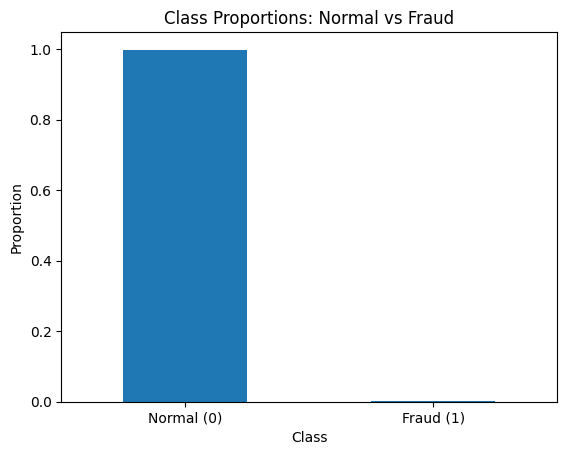

In [20]:
class_proportions.plot(kind="bar")
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"], rotation=0)
plt.ylabel("Proportion")
plt.title("Class Proportions: Normal vs Fraud")
plt.show()


## Train / Test Split

We will:

1. Separate **features** `X` and **target** `y`
2. Split into:
   - **Train + validation** – 80%
   - **Test** – 20%

Later, we will use **Stratified k-fold cross-validation _only_ on `X_train_val, y_train_val`** to train multiple neural networks (with early stopping) and then **ensemble** them on the test set.


**4. Finish the code below to split the data into one dataset for training and validation (80%) and one for testing (20%)**

In [4]:

X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=0
)

X_train_val.shape, X_test.shape


((227845, 29), (56962, 29))


## Helper: Evaluation Function

We will use a helper function to compute multiple metrics at once for a given set of predicted probabilities.


**5. Below is a helper function for calculating the performance metrics as a function of the threshold.  Comment the code to explain what's going on.**

In [6]:
def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "avg_precision": average_precision_score(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba)
    }



## Neural Network + Stratified k-fold Cross-Validation (for Training & Early Stopping)

We now:

- Define neural network architecture.
- Use **StratifiedKFold** on `X_train_val, y_train_val`.
- For each fold:
  - Use that fold's training portion to fit a neural net **with early stopping** (using `early_stopping=True` inside `MLPClassifier`, which carves out a small internal validation set from the training fold).
  - Evaluate on the fold's held-out validation set.
  - Store the trained model.
- In the end we have **k trained neural networks**, each trained on a different subset of the data and early-stopped using its own internal validation.

Later we will **ensemble their predictions on the test set** by averaging the predicted probabilities.


**6. Comment and complete the code below, implementing the k-folding loop.**

In [23]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=0)

fold_models = []
fold_metrics = []

fold_idx = 0

for train_idx, val_idx in cv.split(X_train_val, y_train_val):
    fold_idx += 1
    print(f"\n=== Fold {fold_idx} ===")
    X_tr, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_tr, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
    
    # Define a single NN architecture; no hyperparameter tuning
    mlp_pipeline = Pipeline([
        ("scaler", StandardScaler()),    # this is new for us, it is a preprocessing step that rescales the features 
                                         # so that they each have mean equal to 0, and standard deviation equal to 1
                                         # note: this is done for each fold separately, no data leakage!
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-4,
            max_iter=50,         # upper bound on epochs
            early_stopping=True, # uses 10% of training data internally for early stopping
            n_iter_no_change=5,
            random_state=fold_idx
        ))
    ])
    
    mlp_pipeline.fit(X_tr, y_tr)
    
    # Evaluate on this fold's validation set
    y_val_proba = mlp_pipeline.predict_proba(X_val)[:, 1]           # predict_proba returns the probabilites, two numbers for each event
                                                                    # that sum to one, the second number is P(fraud).
    metrics = evaluate_model(y_val, y_val_proba, threshold=0.5)
    fold_metrics.append(metrics)
    fold_models.append(mlp_pipeline)
    
    for k_metric, v in metrics.items():
        print(f"  {k_metric:12s}: {v:.4f}")



=== Fold 1 ===
  accuracy    : 0.9993
  precision   : 0.8983
  recall      : 0.6795
  f1          : 0.7737
  roc_auc     : 0.9831
  avg_precision: 0.7887
  log_loss    : 0.0032

=== Fold 2 ===
  accuracy    : 0.9995
  precision   : 0.8904
  recall      : 0.8228
  f1          : 0.8553
  roc_auc     : 0.9764
  avg_precision: 0.8282
  log_loss    : 0.0029

=== Fold 3 ===
  accuracy    : 0.9993
  precision   : 0.8429
  recall      : 0.7468
  f1          : 0.7919
  roc_auc     : 0.9434
  avg_precision: 0.7380
  log_loss    : 0.0039

=== Fold 4 ===
  accuracy    : 0.9994
  precision   : 0.8714
  recall      : 0.7722
  f1          : 0.8188
  roc_auc     : 0.9653
  avg_precision: 0.8164
  log_loss    : 0.0034

=== Fold 5 ===
  accuracy    : 0.9994
  precision   : 0.8696
  recall      : 0.7595
  f1          : 0.8108
  roc_auc     : 0.9681
  avg_precision: 0.7717
  log_loss    : 0.0039



### Cross-Validation Performance (Validation Folds)

**7. The metrics for each fold are all stored in a dictionary, get the mean of each metric.** 

In [8]:
# Aggregate fold metrics
keys = fold_metrics[0].keys()
avg_metrics = {k: np.mean([m[k] for m in fold_metrics]) for k in keys}

print("Average validation metrics across folds:")
print("---------------------------------------")
for k_metric, v in avg_metrics.items():
    print(f"{k_metric:12s}: {v:.4f}")


Average validation metrics across folds:
---------------------------------------
accuracy    : 0.9994
precision   : 0.8745
recall      : 0.7562
f1          : 0.8101
roc_auc     : 0.9673
avg_precision: 0.7886
log_loss    : 0.0035



## Ensembling the Fold Models on the Test Set

We now:

1. Use each of the k trained neural nets to predict fraud probabilities on the **test set**.
2. **Ensemble** by averaging the probabilities across folds.
3. Evaluate the **ensemble** on the test set with our metrics.
4. Inspect the confusion matrix and classification report.


**8. Complete the code below to ensemble over the k networks on the test data.**

In [28]:

# Collect probabilities from each fold model
test_probas = []

for i, model in enumerate(fold_models, start=1):
    y_test_proba_i = model.predict_proba(X_test)[:, 1]
    test_probas.append(y_test_proba_i)

# Ensemble: average probabilities across folds
y_test_proba_ens = np.mean(test_probas, axis=0)

ens_metrics = evaluate_model(y_test, y_test_proba_ens, threshold=0.5)

print("Ensembled neural net (average over fold models), threshold = 0.5")
print("----------------------------------------------------------------")
for k_metric, v in ens_metrics.items():
    print(f"{k_metric:12s}: {v:.4f}")


Ensembled neural net (average over fold models), threshold = 0.5
----------------------------------------------------------------
accuracy    : 0.9993
precision   : 0.8642
recall      : 0.7143
f1          : 0.7821
roc_auc     : 0.9668
avg_precision: 0.8251
log_loss    : 0.0031



## ROC Curve and AUC (Ensemble)

The ROC curve plots:

- **True Positive Rate (TPR) = Recall** vs.
- **False Positive Rate (FPR)**

as we vary the classification threshold.


**9. Comment the code below, and understand how it works.**

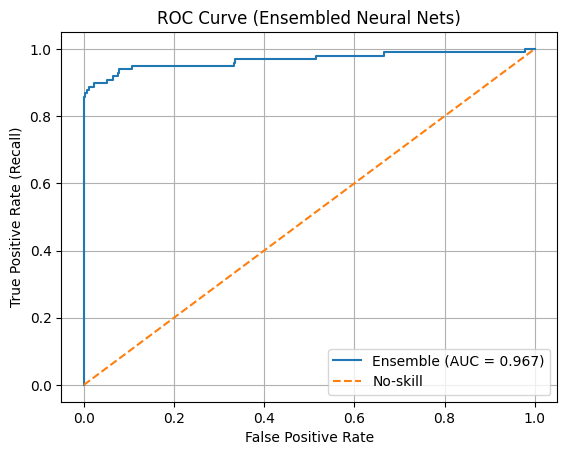

In [31]:

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba_ens)
roc_auc = roc_auc_score(y_test, y_test_proba_ens)

plt.plot(fpr, tpr, label=f"Ensemble (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Ensembled Neural Nets)")
plt.legend()
plt.grid(True)
plt.show()



## Precision--Recall Curve (Ensemble)

For **imbalanced datasets**, the **Precision--Recall (PR) curve** is often more informative.

- x-axis: Recall
- y-axis: Precision

We also show the **baseline precision**, which is the fraction of positive examples.


**10. Comment the code below, and understand how it works.**

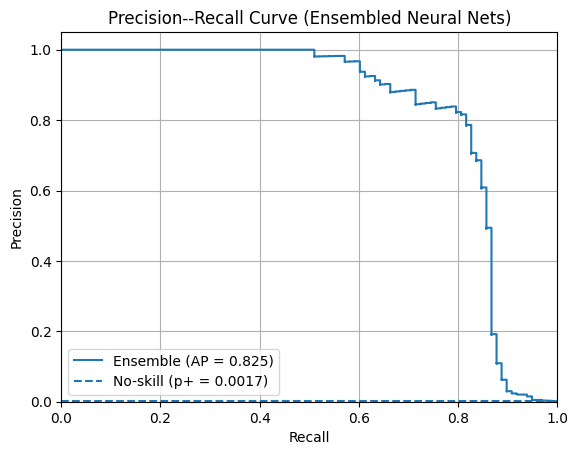

In [32]:

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba_ens)
ap = average_precision_score(y_test, y_test_proba_ens)
baseline = y_test.mean()

plt.step(recall, precision, where="post", label=f"Ensemble (AP = {ap:.3f})")
plt.hlines(baseline, 0, 1, linestyles="--", label=f"No-skill (p+ = {baseline:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision--Recall Curve (Ensembled Neural Nets)")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.legend()
plt.grid(True)
plt.show()



## Threshold Tuning for the Ensemble

The default threshold of 0.5 is arbitrary. For fraud detection, we might care more about **recall** (catching fraud) or we might require a minimum **precision** (not too many false alarms).

Let's scan thresholds and visualise how precision, recall, and F1 change for the **ensemble**.


**11. Comment the code below, and understand how it works.**

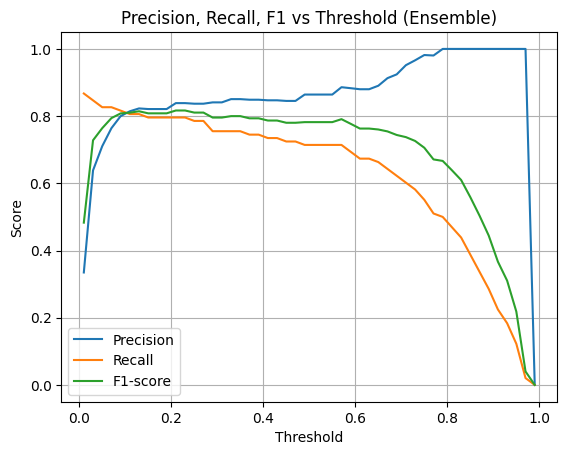

In [33]:
thresholds = np.linspace(0.01, 0.99, 50)
precisions = []
recalls = []
f1s = []

for thr in thresholds:
    y_pred_thr = (y_test_proba_ens >= thr).astype(int)
    precisions.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thr))
    f1s.append(f1_score(y_test, y_pred_thr))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold (Ensemble)")
plt.legend()
plt.grid(True)
plt.show()
